## Parte 0

In [ ]:
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
# !pip install albumentations

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/43.8 MB ? eta -:--:--
   -- ------------------------------------- 2.6/43.8 MB 12.6 MB/s eta 0:00:04
   ---- ----------------------------------- 5.2/43.8 MB 12.8 MB/s eta 0:00:04
   ------ --------------------------------- 6.8/43.8 MB 10.8 MB/s eta 0:00:04
   -------- ------------------------------- 9.7/43.8 MB 11.6 MB/s eta 0:00:03
   ------------ --------------------------- 13.9/43.8 MB 13.2 MB/s eta 0:00:03
   ---------------- ----------------------- 18.4/43.8 MB 14.7 MB/s eta 0:00:02
   -------------------- ------------------- 22.8/43.8 MB 15.5 MB/s eta 0:00:02
   ---------------------- ----------------- 25.2/43.8 MB 14.9 MB/s eta 0:00:02
   -------------------------- ------------- 29.4/43.8 MB 15.4 MB/s eta 0:00:01
   ----------------------------- ---------- 32.2/43.8 MB 15.3 MB/s eta 0:00:01
   ---------------------------------- ----- 37.5/43.8 MB 16.2 MB/s


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\walle\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [81]:
import numpy as np 
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

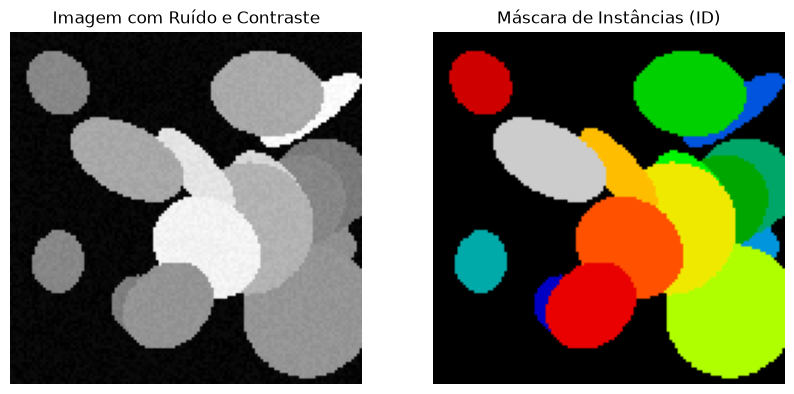

In [82]:
def generateEllipses(img_size):
    # Vamos adicinar um contraste para o fundo da imagem
    bg_intensity = np.random.randint(20,80)
    img = np.full((img_size, img_size), bg_intensity, dtype=np.uint8)

    # Evitar overflow
    mask = np.zeros((img_size, img_size), dtype=np.int32)

    num_ellipses = np.random.randint(15,21)

    # Para cada elipse, define o formato, a posição e a intensidade
    for i in range(1, num_ellipses+1):
        center = (int(np.random.randint(15, img_size-15)), int(np.random.randint(15, img_size-15)))
        axes = (int(np.random.randint(5,25)), int(np.random.randint(5,25)))
        angle = int(np.random.randint(0,180))
        intensity = int(np.random.randint(100,255))

        cv2.ellipse(img, center, axes, angle, 0, 360, intensity, -1)
        cv2.ellipse(mask, center, axes, angle, 0, 360, i, -1)

    std_dev = np.random.uniform(5.0, 30.0)
    noise = np.random.uniform(0, std_dev, (img_size, img_size))

    noisy_img = np.clip(img + noise, 0, 255)

    return noisy_img, mask

img, mask = generateEllipses(128)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagem com Ruído e Contraste")
axes[0].axis('off')

axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title("Máscara de Instâncias (ID)")
axes[1].axis('off')
plt.show()

In [83]:
class EllipsesDataset(Dataset):
  def __init__(self, num_samples) -> None:
     self.num_samples = num_samples
    
  def __len__(self):
    return self.num_samples
  
  def __getitem__(self, index):
    img, mask = generateEllipses(128)
    tensor_img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    tensor_mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
    return tensor_img, tensor_mask

ellip_data_train = EllipsesDataset(800)
ellip_loader_train = DataLoader(ellip_data_train, batch_size=16)

ellip_data_val = EllipsesDataset(200)
ellip_loader_val = DataLoader(ellip_data_val, batch_size=16)

In [132]:
# Para treinar com as elipses criadas acima usaremos a U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(UNet, self).__init__()
        # Encoder
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(128,256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128,64)

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Passa pelo primeiro bloco e salva
        skip1 = self.conv1(x)
        x = self.pool1(skip1)
        skip2 = self.conv2(x)
        x = self.pool2(skip2)


        x = self.bottleneck(x)
        x = self.up1(x)
        x = torch.cat((skip2, x), dim=1)
        x = self.dec1(x)


        x = self.up2(x)
        x = torch.cat((skip1, x), dim=1)
        x = self.dec2(x)

        return self.final_conv(x)
    
   
    def train_routine(
        self,
        loader_train, 
        loader_val, 
        optimizer,  
        epochs: int=50, 
        loss=nn.BCEWithLogitsLoss(), 
        transform_mask=None
    ):

        time_begin = time.time()

        for epoch in range(epochs):
            loss_train = 0.0
            self.train()
            for img, mask in loader_train:
                img = img.to(device)
                mask = mask.to(device)
                # Aplica uma transformacao na mascara, caso desejado
                if not transform_mask is None:
                    mask = transform_mask(mask)

                optimizer.zero_grad()
                pred = self.forward(img)
                loss_value = loss(pred, mask)
                loss_train += loss_value.item()
                loss_value.backward()
                optimizer.step()
            mean_loss_train = loss_train / len(loader_train)

            loss_val = 0.0
            self.eval()
            total_iou = 0.0
            total_dice = 0.0
            with torch.no_grad():
                for img, mask in loader_val:
                    img = img.to(device)
                    mask = mask.to(device)
                    # Aplica uma transformacao na mascara, caso desejado
                    if not transform_mask is None:
                        mask = transform_mask(mask)

                    pred = self.forward(img)
                    loss_value = loss(pred, mask)
                    loss_val += loss_value.item()
                    pred_prob = torch.sigmoid(pred)
                    pred = (pred_prob > 0.5).float()

                    intersection = torch.sum((pred*mask))
                    union = torch.sum((pred+mask)) - intersection
                    iou = intersection / union
                    dice = 2 * intersection / (torch.sum(pred) + torch.sum(mask) + 1e-8)

                    total_iou += iou.item()
                    total_dice += dice.item()
                    
                    
            mean_loss_val = loss_val / len(loader_val)
            mean_iou = total_iou / len(loader_val)
            mean_dice = total_dice / len(loader_val)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1}/50] | Val IoU: {mean_iou:.4f} | Val Dice: {mean_dice:.4f}")
                print(f"Train loss: {mean_loss_train} | Val loss: {mean_loss_val}")

            if mean_iou > 0.99:
                print(f"Early stropping")
                break

        time_end = time.time()
        print(f"Train time: {(time_end - time_begin)/60} minutes")

In [ ]:
# Treino do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_channels=1).to(device)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

time_begin = time.time()

for epoch in range(50):
  loss_train = 0.0
  model.train()
  for img, mask in ellip_loader_train:
    img = img.to(device)
    mask = mask.to(device)
    mask = (mask > 0).float()

    optimizer.zero_grad()
    pred = model(img)
    loss_value = loss(pred, mask)
    loss_train += loss_value.item()
    loss_value.backward()
    optimizer.step()
  mean_loss_train = loss_train / len(ellip_loader_train)

  loss_val = 0.0
  model.eval()
  total_iou = 0.0
  total_dice = 0.0
  with torch.no_grad():
    for img, mask in ellip_loader_val:
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()

      pred = model(img)
      loss_value = loss(pred, mask)
      loss_val += loss_value.item()
      pred_prob = torch.sigmoid(pred)
      pred = (pred_prob > 0.5).float()

      intersection = torch.sum((pred*mask))
      union = torch.sum((pred+mask)) - intersection
      iou = intersection / union
      dice = 2 * intersection / (torch.sum(pred) + torch.sum(mask) + 1e-8)

      total_iou += iou.item()
      total_dice += dice.item()
  mean_loss_val = loss_val / len(ellip_loader_val)
  mean_iou = total_iou / len(ellip_loader_val)
  mean_dice = total_dice / len(ellip_loader_val)

  if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"Epoch [{epoch+1}/50] | Val IoU: {mean_iou:.4f} | Val Dice: {mean_dice:.4f}")
      print(f"Train loss: {mean_loss_train} | Val loss: {mean_loss_val}")

  if mean_iou > 0.99:
    print(f"Early stropping")
    break

time_end = time.time()
print(f"Train time: {(time_end - time_begin)/60} minutes")


Epoch [1/50] | Val IoU: 0.9928 | Val Dice: 0.9964
Train loss: 0.12775792606174946 | Val loss: 0.05787286993402701
Early stropping
Train time: 0.15530187288920086 minutes


In [126]:
def binarize_mask(mask):
    return (mask > 0).float()

In [133]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train_routine(
    loader_train=ellip_loader_train, 
    loader_val=ellip_loader_val, 
    optimizer=optimizer,
    epochs=50, 
    loss=nn.BCEWithLogitsLoss(), 
    transform_mask=binarize_mask
)

Epoch [1/50] | Val IoU: 0.9968 | Val Dice: 0.9984
Train loss: 0.10919171199202538 | Val loss: 0.053287312388420105
Early stropping
Train time: 1.7030209342638651 minutes


# Parte 1

In [86]:
class BBBC038Dataset(Dataset):

    def __init__(self, root, transform):
        self.root = Path(root)

        # Encontra todas as imagens 
        self.images = sorted(self.root.glob("*/images/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]

        # Pasta correspondente a imagem
        sample_dir = image_path.parent.parent

        # Carrega a imagem em um tensor
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # (BGR ==> RGB)

        # Carrega as mascaras
        mask_paths = sorted((sample_dir / "masks").glob("*.png"))

        masks = []

        for i in range(len(mask_paths)):
            mask_path = mask_paths[i]
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask != 0) * (i + 1)
            masks.append(mask)

        mask = np.stack(masks).max(0).astype(int)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = mask.unsqueeze(0).float()

        return image, mask

In [123]:
# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # Forca image e mask para 256x256
    A.Resize(height=256, width=256),
    
    # Normaliza os pixels para o padrao ImageNet
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    
    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W)) 
    ToTensorV2()
])

batch_size = 16

dataset = BBBC038Dataset("data/stage1_train", train_transform)
dataloader = DataLoader(dataset, batch_size=batch_size)

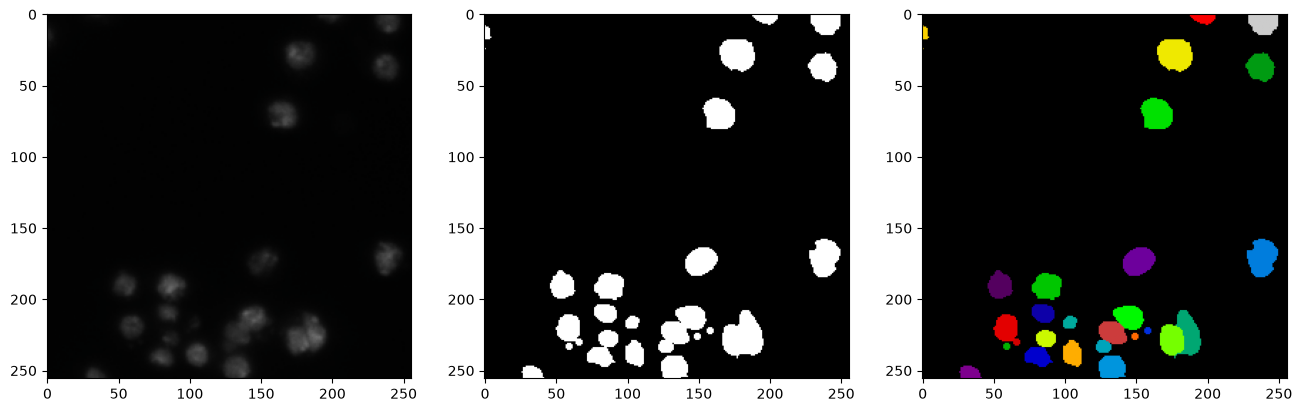

In [102]:
for i, (img, mask) in enumerate(dataloader):
    img = img.to(device)
    mask = mask.to(device)
    
    # Desfaz a normalizacao da imagem
    img_plot = img[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_plot = (img_plot * std) + mean
    img_plot = np.clip(img_plot, 0, 1)
    
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 10))
    mask = mask[0][0].cpu().numpy()
    axes[0].imshow(img_plot)
    axes[1].imshow(mask != 0, cmap='gray')
    axes[2].imshow(mask, cmap='nipy_spectral')
    break

In [142]:
# Treino do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train_routine(
    loader_train=dataloader, # Trocar por treino e validacao
    loader_val=dataloader, 
    optimizer=optimizer,
    epochs=1, 
    loss=nn.BCEWithLogitsLoss(), 
    transform_mask=binarize_mask
)

Epoch [1/50] | Val IoU: 0.5530 | Val Dice: 0.7102
Train loss: 0.32194998186259044 | Val loss: 0.26021574224744526
Train time: 14.045865301291148 minutes


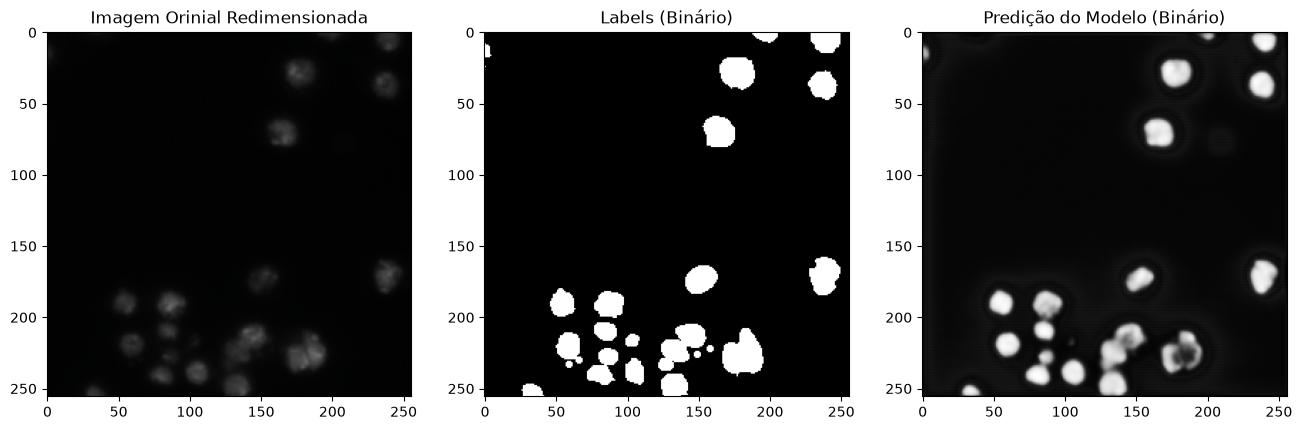

In [144]:
with torch.no_grad():
    for i, (img, mask) in enumerate(dataloader):
      if i != 0: continue
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()
      
      
      # Desfaz a normalizacao da imagem
      img_plot = img[0].cpu().permute(1, 2, 0).numpy()
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img_plot = (img_plot * std) + mean
      img_plot = np.clip(img_plot, 0, 1)
      pred = model(img)
      pred = torch.sigmoid(pred)[0].cpu().numpy()
      
      
      fig, axes = plt.subplots(1, 3, figsize=(16, 10))
      axes[0].imshow(img_plot)
      axes[0].set(
        title="Imagem Orinial Redimensionada"
      )
      axes[1].imshow(mask[0][0].cpu().numpy(), cmap='gray')
      axes[1].set(
        title="Labels (Binário)"
      )
      axes[2].imshow(pred[0], cmap='gray')
      axes[2].set(
        title="Predição do Modelo (Binário)"
      )
      break

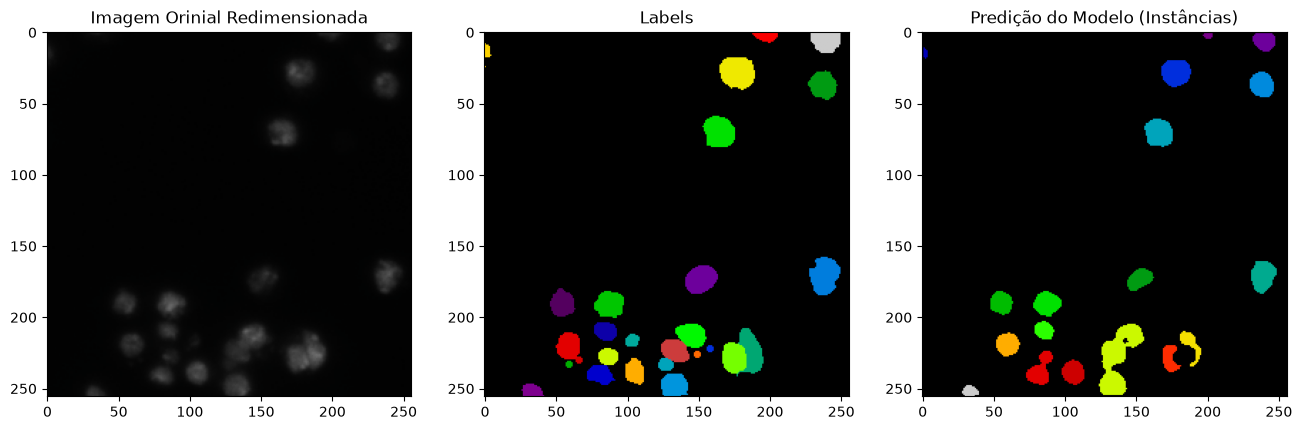

In [145]:
# Extrair instâncias pelo método ingênuo
from scipy.ndimage import label
import matplotlib.colors as mcolors

with torch.no_grad():
    for i, (img, mask) in enumerate(dataloader):
      img = img.to(device)
      mask = mask.to(device)
      
      # Desfaz a normalizacao da imagem
      img_plot = img[0].cpu().permute(1, 2, 0).numpy()
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img_plot = (img_plot * std) + mean
      img_plot = np.clip(img_plot, 0, 1)

      pred = model(img)
      pred = torch.sigmoid(pred)[0].cpu().numpy()
      # Limiar   
      pred_bin = (pred > 0.5).astype(int)
      # Componentes Conexas
      inst_matrix, num_obj = label(pred_bin)
      
      fig, axes = plt.subplots(1, 3, figsize=(16, 10))
      axes[0].imshow(img_plot)
      axes[0].set(
        title="Imagem Orinial Redimensionada"
      )
      axes[1].imshow(mask[0][0].cpu().numpy(), cmap='nipy_spectral')
      axes[1].set(
        title="Labels"
      )
      axes[2].imshow(inst_matrix[0], cmap='nipy_spectral')
      axes[2].set(
        title="Predição do Modelo (Instâncias)"
      )
      break

In [146]:
def compute_intersection(mask_true, mask_pred):
    mask_true = np.asarray(mask_true)
    mask_pred = np.asarray(mask_pred)
    
    # Calcula a quantidade de pixels de cada instancia na mascara real
    true_inst_counts = np.unique_counts(mask_true)
    true_instances_counts = dict(zip(true_inst_counts.values, true_inst_counts.counts))
    
    # Calcula a quantidade de pixels de cada instancia na mascara prevista
    pred_inst_counts = np.unique_counts(mask_pred)
    pred_instances_counts = dict(zip(pred_inst_counts.values, pred_inst_counts.counts))
    
    # Calcula as intersecoes
    intersect_matrix = np.array([
        [0.0 for true_class in range(len(true_inst_counts.values))]
        for pred_class in range(len(pred_inst_counts.values))
    ])
    fn_matrix = intersect_matrix.copy()
    fp_matrix = intersect_matrix.copy()
    
    intersect = np.hstack([mask_pred.reshape(-1, 1), mask_true.reshape(-1, 1)]).astype(int)
    
    # Soma as intersecoes a matrix
    intersect_values, intersect_counts = np.unique(intersect, axis=0, return_counts=True)
    for (pred_inst, true_inst), qtd in zip(list(intersect_values), intersect_counts):
        qtd = float(qtd)
        intersect_matrix[pred_inst][true_inst] += qtd
        fn_matrix[pred_inst][true_inst] = true_instances_counts.get(true_inst, 0) - qtd
        fp_matrix[pred_inst][true_inst] = pred_instances_counts.get(pred_inst, 0) - qtd
        
    
    # Computa o iou
    iou_matrix = intersect_matrix.copy()
    iou_matrix[iou_matrix != 0] = iou_matrix[iou_matrix != 0] / (
        iou_matrix[iou_matrix != 0] 
        + fn_matrix[iou_matrix != 0] 
        + fp_matrix[iou_matrix != 0]
    )
        
    return intersect_matrix, iou_matrix

In [147]:
def greedy_match(iou, predicts):
    iou = iou.copy()
    # Faz o casamento de forma gulosa
    matches = np.full(shape=predicts, fill_value=0.0)
    for _ in range(predicts):
        pred_mxs = iou.max(axis=1)
        greedy_pred_isnt = pred_mxs.argmax()
        greedy_true_isnt = iou[greedy_pred_isnt].argmax()
        greedy_iou = iou[greedy_pred_isnt, greedy_true_isnt].max()
        
        # Apaga virtualmente as instancias prevista e verdadeira
        iou[greedy_pred_isnt, :] = -1
        iou[:, greedy_true_isnt] = -1
        
        matches[greedy_pred_isnt] = greedy_iou
        
    return matches
        
        
def test_limiares(iou, limiares, predicts, trues):
    matches = greedy_match(iou, predicts)
    
    true_positives = []
    false_positves = []
    false_negatives = []
    average_precisions = []
    
    # Calcula TP, FP e FN para cada limiar
    for limiar in limiares:
        tp = (matches >= limiar).sum()
        fp = predicts - tp
        fn = trues - tp
        true_positives.append(tp)
        false_positves.append(fp)
        false_negatives.append(fn)
        average_precisions.append(tp / (tp + fp + fn))
        
    return true_positives, false_positves, false_negatives, average_precisions


def compute_metrics(iou_matrix, limiares):
    iou = iou_matrix[1:, 1:] 
    predicts, trues = iou.shape
    true_positives, false_positves, false_negatives, average_precisions = test_limiares(iou, limiares, predicts, trues)
    mean_average_precision = np.mean(average_precisions)
    abs_count_error = np.abs(predicts - trues)
    
    return true_positives, false_positves, false_negatives, float(mean_average_precision), float(abs_count_error)

In [148]:
mask_true = None
mask_pred = None
with torch.no_grad():
    for i, (img, mask) in enumerate(dataloader):
        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)
        pred = torch.sigmoid(pred)[0].cpu().numpy()
        # Limiar   
        pred_bin = (pred > 0.5).astype(int)
        # Componentes Conexas
        inst_matrix, num_obj = label(pred_bin)
        
        mask_true = mask[0][0].cpu().numpy()
        mask_pred = inst_matrix[0]
        
        break

In [149]:
intersect_matrix, iou_matrix = compute_intersection(mask_true=mask_true, mask_pred=mask_pred)

true_positives, false_positves, false_negatives, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

In [150]:
np.vstack([true_positives, false_positves, false_negatives]).T

array([[14,  4, 13],
       [13,  5, 14],
       [12,  6, 15],
       [ 9,  9, 18],
       [ 8, 10, 19],
       [ 7, 11, 20],
       [ 3, 15, 24],
       [ 0, 18, 27],
       [ 0, 18, 27],
       [ 0, 18, 27]])

Para realizar o matching entre a nossa mask e o que foi predito por nosso modelo, temos duas opções a considerar: guloso por IoU decrescente ou Hungarian. 

Antes de documentar os métodos, vale a pena descrever como obtivemos a matriz que será usada no matching: calcula-se a quantidade de pixels de cada instância, tanto na mask quanto no que foi previsto; após isto, coloca-se cada pixel da mask ao lado de sua previsao correspondente e conta-se a quantidade de ocorrências de cada par (classe real, classe prevista); com isto, passamos por cada par único usando a quantidade de ocorrências desse par e as quantidades de ocorrências da classe prevista e da classe real, obtendo então os FPs e os FNs (previstos = interseção + FPs e verdadeiros = interseção + FNs); com a interseção e as áreas totais (ou FPs e FNs), calcula-se a união e, consequentemente, o IoU de cada par  

O método guloso por IoU decrescente, que na nossa aplicação é $O(n^{2})$, vai pegar a célula de maior valor, atribuir à previsão linha a classe coluna, remover as linhas e colunas correspondentes a essa célula e repetir esse procedimento até que não sobre mais nenhum IoU aceitável (nosso threshold).

Já o Hungarian, também chamado de algoritmo de Kuhn-Munkres, é um algoritmo de complexidade $O(n^{3})$ que pode ser usado para encontrar emparelhamentos de peso máximo em grafos bipartidos, o que às vezes é chamado de problema de atribuição.

Como o objetivo desta etapa não é usar o melhor algoritmo possível e temos uma quantidade considerável de dados, optamos por seguir com o método guloso

In [115]:
ax_x_density = []
ax_y_error = []

with torch.no_grad():
    for i, (img, mask) in enumerate(dataloader):
        img = img.to(device)
        mask = mask.cpu().numpy()

        pred = model(img)
        pred = torch.sigmoid(pred).cpu().numpy()
   
        for b in range(img.shape[0]):
            # Trata a Previsão (Limiar + Componentes Conexos)
            pred_bin = (pred[b, 0] > 0.5).astype(int)
            inst_matrix_pred, _ = label(pred_bin)
            
            # Trata o Gabarito 
            mask_bin = (mask[b, 0] > 0).astype(int)
            inst_matrix_true, _ = label(mask_bin)
            
            
            intersect_matrix, iou_matrix = compute_intersection(
                mask_true=inst_matrix_true, 
                mask_pred=inst_matrix_pred
            )

            # Se a imagem for totalmente preta (sem células), pulamos para evitar erro
            if iou_matrix.shape == (1, 1):
                continue

            true_positives, false_positves, false_negatives, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

            ax_x_density.append(iou_matrix.shape[1] - 1)
            ax_y_error.append(abs_count_error)

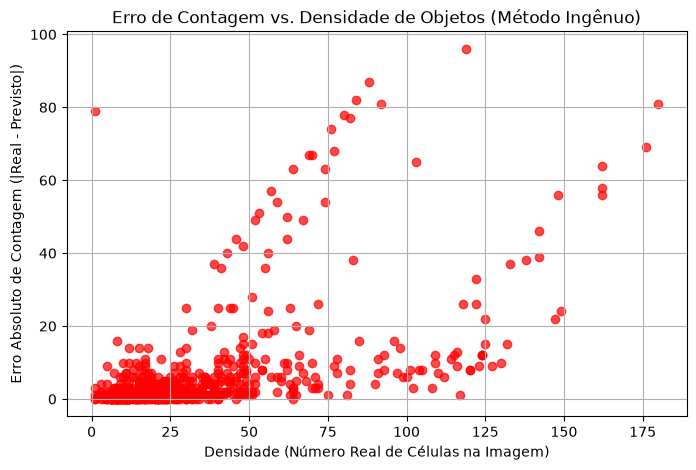

In [151]:
ax_x_density = np.array(ax_x_density)
ax_y_error = np.array(ax_y_error)
plt.figure(figsize=(8, 5))
plt.scatter(ax_x_density[ax_x_density < 200], ax_y_error[ax_x_density < 200], alpha=0.7, color='red')
plt.title("Erro de Contagem vs. Densidade de Objetos (Método Ingênuo)")
plt.xlabel("Densidade (Número Real de Células na Imagem)")
plt.ylabel("Erro Absoluto de Contagem (|Real - Previsto|)")
plt.grid(True)
plt.show()

# Parte 2